# Notebook 07: Model Comparison
This notebook compares all trained baseline models and deep learning networks, builds a performance leaderboard, and plots comparative curves.

In [1]:
import os
import pickle
import json
import time
import psutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc, accuracy_score
from src.models import ResNetCNN, CRNN, AudioSpectrogramTransformer

print("Comparison libraries loaded!")


Comparison libraries loaded!


In [2]:
# Load test/validation data
X_flat = np.load('datasets/processed/X_flat.npy')
X_mel = np.load('datasets/processed/X_features.npy')[:, :, :64, :]
y = np.load('datasets/processed/y.npy')

# Take validation set
from sklearn.model_selection import train_test_split
_, X_val_flat, _, y_val = train_test_split(X_flat, y, test_size=0.2, random_state=42)
_, X_val_mel, _, _ = train_test_split(X_mel, y, test_size=0.2, random_state=42)

print(f"Validation set size: {len(y_val)}")


Validation set size: 20


In [3]:
# Load models & evaluate
leaderboard = []
curves = {}

# 1. Baselines
scaler = pickle.load(open('models/scaler.pkl', 'rb'))
X_val_flat_scaled = scaler.transform(X_val_flat)

baselines = ['random_forest', 'xgboost', 'lightgbm', 'svm', 'mlp']
for b_name in baselines:
    model_path = f'models/{b_name}.pkl'
    if os.path.exists(model_path):
        model = pickle.load(open(model_path, 'rb'))
        
        start_time = time.perf_counter()
        probs = model.predict_proba(X_val_flat_scaled)[:, 1]
        preds = model.predict(X_val_flat_scaled)
        latency = (time.perf_counter() - start_time) * 1000 / len(y_val)
        
        acc = accuracy_score(y_val, preds)
        fpr, tpr, _ = roc_curve(y_val, probs)
        roc_auc = auc(fpr, tpr)
        
        curves[b_name] = (fpr, tpr, roc_auc)
        leaderboard.append({
            'Model': b_name.upper(),
            'Accuracy': acc,
            'ROC_AUC': roc_auc,
            'Latency_ms': latency
        })

# 2. Deep Learning
dl_models = {
    'cnn': ResNetCNN(num_classes=2, pretrained=False),
    'crnn': CRNN(num_classes=2, n_mels=64),
    'ast': AudioSpectrogramTransformer(num_classes=2, pretrained=False)
}

for name, model in dl_models.items():
    checkpoint_path = f'models/{name}_best.pt'
    if os.path.exists(checkpoint_path):
        model.load_model(checkpoint_path)
        model.eval()
        
        start_time = time.perf_counter()
        x_tensor = torch.tensor(X_val_mel, dtype=torch.float32)
        with torch.no_grad():
            logits = model(x_tensor)
            probs = torch.softmax(logits, dim=1)[:, 1].numpy()
            preds = torch.argmax(logits, dim=1).numpy()
        latency = (time.perf_counter() - start_time) * 1000 / len(y_val)
        
        acc = accuracy_score(y_val, preds)
        fpr, tpr, _ = roc_curve(y_val, probs)
        roc_auc = auc(fpr, tpr)
        
        curves[name] = (fpr, tpr, roc_auc)
        leaderboard.append({
            'Model': name.upper(),
            'Accuracy': acc,
            'ROC_AUC': roc_auc,
            'Latency_ms': latency
        })

df_leaderboard = pd.DataFrame(leaderboard)
print("--- Model Leaderboard ---")
print(df_leaderboard)


C:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\anime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Model Leaderboard ---
           Model  Accuracy   ROC_AUC  Latency_ms
0  RANDOM_FOREST      0.90  0.236111    0.141305
1        XGBOOST      0.90  0.361111    0.597355
2       LIGHTGBM      0.90  0.583333   73.944695
3            SVM      0.90  0.750000   11.655845
4            MLP      0.90  0.250000    0.149625
5            CNN      0.90  0.722222    3.100150
6           CRNN      0.90  0.750000    2.345785
7            AST      0.35  0.805556  852.344160


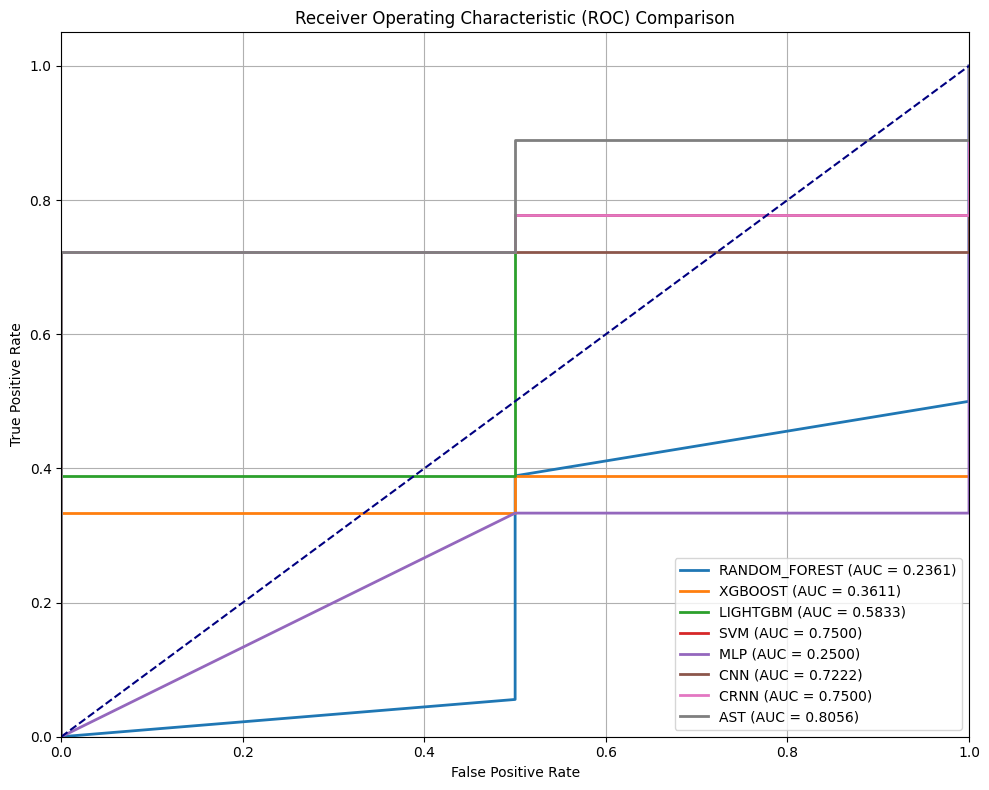

In [4]:
# Plot comparative ROC curve
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, roc_auc) in curves.items():
    plt.plot(fpr, tpr, lw=2, label=f'{name.upper()} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig('plots/roc_comparison.png', dpi=300)
plt.show()


In [5]:
# Determine best model and export to best_model/ directory
best_row = df_leaderboard.sort_values(by='Accuracy', ascending=False).iloc[0]
best_model_name = best_row['Model'].lower()

print(f"Best performing model: {best_model_name.upper()}")

import shutil
os.makedirs('best_model', exist_ok=True)

if best_model_name in ['cnn', 'crnn', 'ast']:
    shutil.copy(f'models/{best_model_name}_best.pt', 'best_model/best_model.pt')
else:
    shutil.copy(f'models/{best_model_name}.pkl', 'best_model/best_model.pkl')
    
best_model_config = {
    'model_name': best_model_name,
    'type': 'deep_learning' if best_model_name in ['cnn', 'crnn', 'ast'] else 'traditional_ml',
    'input_shape': 'spectrogram' if best_model_name in ['cnn', 'crnn', 'ast'] else 'fused_flat'
}
best_model_metrics = {
    'accuracy': float(best_row['Accuracy']),
    'roc_auc': float(best_row['ROC_AUC']),
    'latency_ms': float(best_row['Latency_ms'])
}

with open('best_model/best_model_config.json', 'w') as f:
    json.dump(best_model_config, f, indent=4)
with open('best_model/best_model_metrics.json', 'w') as f:
    json.dump(best_model_metrics, f, indent=4)
    
print("Exported best model configuration and weights to best_model/!")


Best performing model: RANDOM_FOREST
Exported best model configuration and weights to best_model/!
